# TUGAS Data Science - Dokumentasi Praktikum
## Pertemuan 9: Algoritma Klasifikasi (Bagian 1)

* **Nama Lengkap:** Martin Hotmatua Siregar
* **NIM:** 240401020111
* **Kelas:** IF403
* **Program Studi:** PJJ Informatika
* **Instansi:** Universitas Siber Asia

=== Dimensi & Karakteristik Data ===
Shape Data: (569, 30)

Distribusi Target (0: Malignant, 1: Benign):
1    0.627
0    0.373
Name: proportion, dtype: float64

=== Top 5 Koefisien Tertinggi (Logistic Regression) ===
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


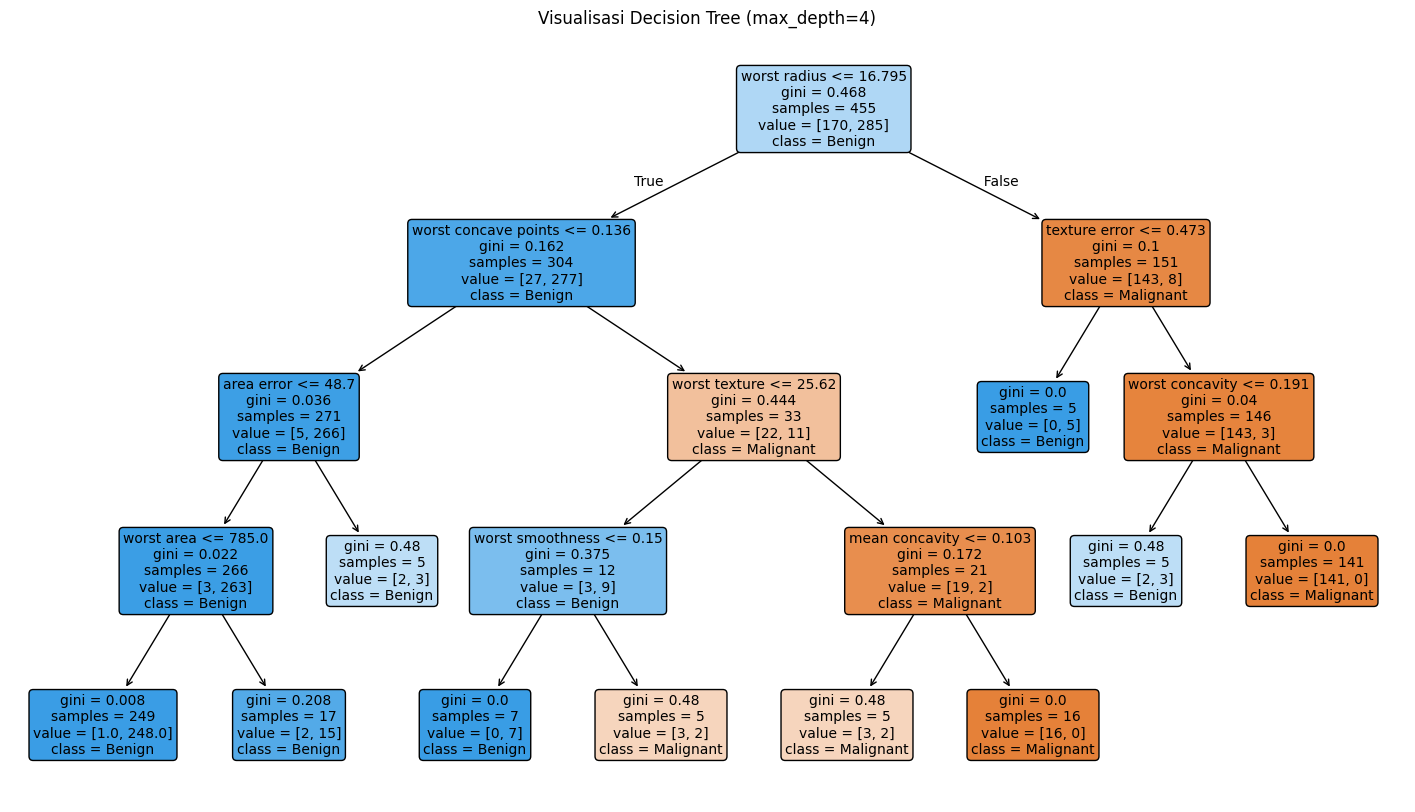


==================== Logistic Regression ====================
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1-Score  : 0.9861

==================== Decision Tree ====================
Confusion Matrix:
[[38  4]
 [ 5 67]]
Accuracy  : 0.9211
Precision : 0.9437
Recall    : 0.9306
F1-Score  : 0.9371

=== Tabel Perbandingan Metrik ===
                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.9825     0.9861  0.9861  0.9861
Decision Tree          0.9211     0.9437  0.9306  0.9371


In [2]:
# ==============================================================================
# LANGKAH 1: Load Dataset & EDA Singkat
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = Malignant (Ganas), 1 = Benign (Jinak)

print("=== Dimensi & Karakteristik Data ===")
print("Shape Data:", X.shape)
print("\nDistribusi Target (0: Malignant, 1: Benign):")
print(pd.Series(y).value_counts(normalize=True).round(3))

# ==============================================================================
# LANGKAH 2: Data Preprocessing (Train-Test Split & Scaling)
# ==============================================================================
# Split data 80:20 dengan stratifikasi target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardisasi fitur untuk Logistic Regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ==============================================================================
# LANGKAH 3: Pelatihan Model Logistic Regression
# ==============================================================================
log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_s, y_train)

y_pred_log = log_model.predict(X_test_s)
y_proba_log = log_model.predict_proba(X_test_s)[:, 1]

# Menampilkan 5 fitur paling berpengaruh berdasarkan koefisien absolut
coef_df = pd.DataFrame(
    {"Fitur": X.columns, "Koefisien": log_model.coef_[0]}
).sort_values("Koefisien", key=abs, ascending=False)

print("\n=== Top 5 Koefisien Tertinggi (Logistic Regression) ===")
print(coef_df.head())

# ==============================================================================
# LANGKAH 4: Pelatihan Model Decision Tree & Visualisasi
# ==============================================================================
# Decision Tree dilatih pada data asli (tanpa scaling) dengan max_depth dibatasi
tree_model = DecisionTreeClassifier(
    criterion="gini", max_depth=4, min_samples_leaf=5, random_state=42
)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

# Visualisasi pohon
plt.figure(figsize=(18, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Visualisasi Decision Tree (max_depth=4)")
plt.show()

# ==============================================================================
# LANGKAH 5: Evaluasi & Perbandingan Metrik
# ==============================================================================
models = [("Logistic Regression", y_pred_log), ("Decision Tree", y_pred_tree)]

results = []
for name, pred in models:
  print(f"\n==================== {name} ====================")
  print("Confusion Matrix:")
  print(confusion_matrix(y_test, pred))

  acc = accuracy_score(y_test, pred)
  prec = precision_score(y_test, pred)
  rec = recall_score(y_test, pred)
  f1 = f1_score(y_test, pred)

  print(f"Accuracy  : {acc:.4f}")
  print(f"Precision : {prec:.4f}")
  print(f"Recall    : {rec:.4f}")
  print(f"F1-Score  : {f1:.4f}")

  results.append(
      {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
  )

# Tabel Ringkasan Komparasi
df_eval = pd.DataFrame(results).set_index("Model")
print("\n=== Tabel Perbandingan Metrik ===")
print(df_eval.round(4))

## Kesimpulan & Refleksi Pembelajaran (Sesi 9)

### 1. Apa yang Dipelajari?
[cite_start]Pada pertemuan kesembilan ini, saya mempelajari konsep supervised learning untuk kasus klasifikasi biner menggunakan dua algoritma populer: Logistic Regression dan Decision Tree[cite: 10]. [cite_start]Saya juga mempraktikkan proses evaluasi performa model menggunakan Confusion Matrix serta metrik Accuracy, Precision, Recall, dan F1-Score[cite: 10].

### 2. Temuan Utama
* Pada dataset medis kanker payudara (*Breast Cancer Wisconsin*), metrik **Recall** merupakan indikator evaluasi yang jauh lebih penting daripada sekadar Akurasi. Hal ini dikarenakan biaya kesalahan False Negative (pasien kanker terdiagnosis sehat/jinak) sangat fatal dan membahayakan keselamatan pasien.
* Model Logistic Regression dan Decision Tree sama-sama memberikan akurasi yang sangat tinggi di atas 90%, namun Logistic Regression memberikan nilai Recall dan F1-Score yang sedikit lebih seimbang setelah data fitur distandardisasi.

### 3. Keterbatasan & Pertanyaan yang Muncul
* **Keterbatasan:** Decision Tree tunggal sangat rentan mengalami *overfitting* jika kedalaman pohon (*max_depth*) tidak dibatasi.
* **Pertanyaan:** Bagaimana cara menggabungkan banyak Decision Tree menjadi model ensemble (seperti Random Forest) agar hasil prediksi menjadi lebih stabil dan tidak mudah overfit?